In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np

In [2]:
(ds_train, ds_test), info = tfds.load(
    "cifar10",
    split=["train", "test"],
    as_supervised=True,
    with_info=True
)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cifar10/incomplete.V3RVSJ_3.0.2/cifar10-train.tfrecord*...:   0%|         …

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cifar10/incomplete.V3RVSJ_3.0.2/cifar10-test.tfrecord*...:   0%|          …

Dataset cifar10 downloaded and prepared to /root/tensorflow_datasets/cifar10/3.0.2. Subsequent calls will reuse this data.


In [3]:
def preprocess(image, label):
    image = tf.image.resize(image, (96, 96))
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

ds_train = ds_train.map(preprocess).batch(8)
ds_test = ds_test.map(preprocess).batch(8)

In [4]:
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(64, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10)
])

model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

model.fit(ds_train, epochs=1)

6250/6250 ━━━━━━━━━━━━━━━━━━━━ 52s 8ms/step - accuracy: 0.4209 - loss: 1.6191


In [5]:
teacher = model
teacher.trainable = False

In [6]:
student = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10)
])

In [10]:
train_acc_list = []
train_loss_list = []

temperature = 3
alpha = 0.5

ce_loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
kl_loss = tf.keras.losses.KLDivergence()

optimizer = tf.keras.optimizers.Adam()

for epoch in range(3):
    print("Epoch:", epoch+1)

    epoch_loss = 0
    correct = 0
    total = 0

    for images, labels in ds_train:
        with tf.GradientTape() as tape:

            teacher_preds = teacher(images, training=False)
            student_preds = student(images, training=True)

            soft_teacher = tf.nn.softmax(teacher_preds / temperature)
            soft_student = tf.nn.softmax(student_preds / temperature)

            loss_soft = kl_loss(soft_teacher, soft_student)
            loss_hard = ce_loss(labels, student_preds)

            loss = alpha * loss_soft + (1 - alpha) * loss_hard

        grads = tape.gradient(loss, student.trainable_variables)
        optimizer.apply_gradients(zip(grads, student.trainable_variables))

        # Track loss
        epoch_loss += loss.numpy()

        # Track accuracy
        preds = tf.argmax(student_preds, axis=1)
        correct += tf.reduce_sum(tf.cast(preds == labels, tf.int32)).numpy()
        total += labels.shape[0]

    epoch_acc = correct / total
    epoch_loss = epoch_loss / total

    train_acc_list.append(epoch_acc)
    train_loss_list.append(epoch_loss)

    print(f"Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.4f}")

Epoch: 1
Loss: 0.0755, Accuracy: 0.6005
Epoch: 2
Loss: 0.0721, Accuracy: 0.6240
Epoch: 3
Loss: 0.0693, Accuracy: 0.6444


In [12]:
student.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

student.evaluate(ds_test)

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5156 - loss: 1.4105


[1.4104914665222168, 0.5156000256538391]

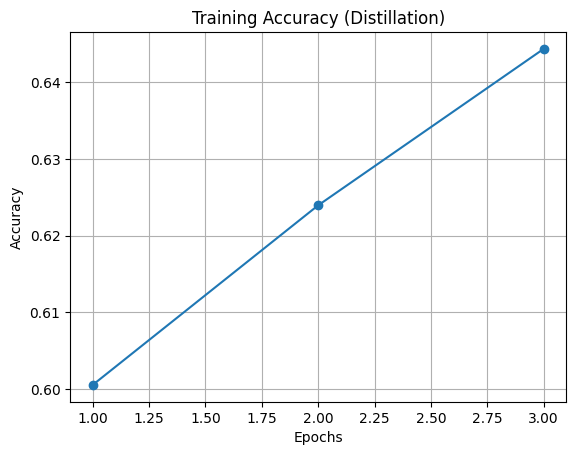

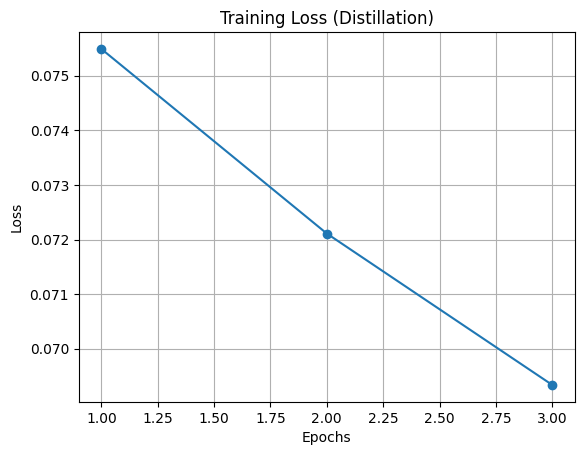

In [11]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(train_acc_list) + 1)

# Accuracy Graph
plt.figure()
plt.plot(epochs_range, train_acc_list, marker='o')
plt.title("Training Accuracy (Distillation)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.grid()
plt.show()

# Loss Graph
plt.figure()
plt.plot(epochs_range, train_loss_list, marker='o')
plt.title("Training Loss (Distillation)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid()
plt.show()

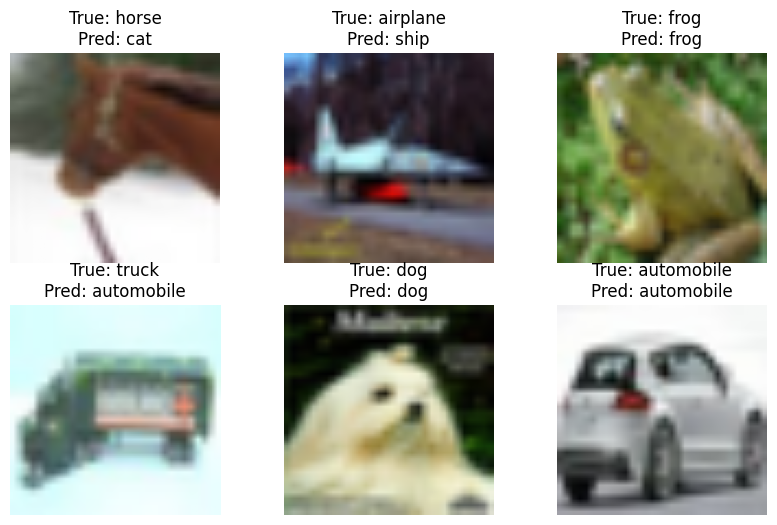

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# CIFAR-10 class names
class_names = [
    "airplane","automobile","bird","cat","deer",
    "dog","frog","horse","ship","truck"
]

# Take one batch
for images, labels in ds_test.take(1):

    # Get predictions
    preds = student(images, training=False)
    pred_labels = tf.argmax(preds, axis=1)

    plt.figure(figsize=(10,6))

    for i in range(6):   # show 6 images
        plt.subplot(2, 3, i+1)

        plt.imshow(images[i])
        plt.title(
            f"True: {class_names[labels[i]]}\n"
            f"Pred: {class_names[pred_labels[i]]}"
        )
        plt.axis("off")

    plt.show()